# Proyecto 2 — Análisis Exploratorio
## Reto #17 — MosquitoAlert Challenge 2023 (AIcrowd)
**CC3084 — Data Science | UVG | Semestre II — 2026**

Competencia: https://www.aicrowd.com/challenges/mosquitoalert-challenge-2023

In [67]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)

RANDOM_SEED = 24
np.random.seed(RANDOM_SEED)


In [68]:
DATA_DIR = "../data/raw"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
IMAGES_DIR = os.path.join(DATA_DIR, "images")

# Distribución oficial de clases reportada por AIcrowd para el subset de entrenamiento (8025 imgs)
OFFICIAL_CLASS_COUNTS = {
    "aegypti": 38,
    "albopictus": 3567,
    "anopheles": 63,
    "culex": 3544,
    "culiseta": 492,
    "japonicus/koreicus": 321,
}

def make_synthetic_train_df(class_counts=OFFICIAL_CLASS_COUNTS, seed=RANDOM_SEED):
    """Genera un DataFrame sintético con la misma forma que train.csv del reto,
    replicando la proporción real de clases (útil para probar el pipeline de EDA
    antes de tener el dataset real descargado)."""
    rng = np.random.default_rng(seed)
    rows = []
    img_id = 0
    for cls, n in class_counts.items():
        for _ in range(n):
            width = int(rng.normal(1200, 250))
            height = int(rng.normal(900, 200))
            width, height = max(width, 200), max(height, 200)
            bw = rng.uniform(0.05, 0.4) * width
            bh = rng.uniform(0.05, 0.4) * height
            xtl = rng.uniform(0, width - bw)
            ytl = rng.uniform(0, height - bh)
            rows.append({
                "img_fname": f"synthetic_{img_id:05d}.jpeg",
                "width": width,
                "height": height,
                "bbx_xtl": round(xtl, 1),
                "bbx_ytl": round(ytl, 1),
                "bbx_xbr": round(xtl + bw, 1),
                "bbx_ybr": round(ytl + bh, 1),
                "class_label": cls,
            })
            img_id += 1
    df = pd.DataFrame(rows).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return df

USE_REAL_DATA = os.path.exists(TRAIN_CSV)

if USE_REAL_DATA:
    train_df = pd.read_csv(TRAIN_CSV)
    print(f"Datos reales cargados desde {TRAIN_CSV} — {len(train_df)} filas.")
else:
    train_df = make_synthetic_train_df()
    print("DEMO MODE: no se encontró data/raw/train.csv — usando datos sintéticos "
          f"({len(train_df)} filas) solo para validar el pipeline. "
          "Reemplacen con el dataset real antes de la entrega.")

train_df.head()


Datos reales cargados desde ../data/raw\train.csv — 10357 filas.


,img_fName,img_w,img_h,bbx_xtl,bbx_ytl,bbx_xbr,bbx_ybr,class_label
0,train_00000.jpeg,2448,3264,1301,1546,1641,2096,albopictus
1,train_00001.jpeg,3024,4032,900,1897,1950,2990,albopictus
2,train_00002.jpeg,768,1024,220,58,659,808,albopictus
3,train_00003.jpeg,3456,4608,1169,2364,1586,2826,albopictus
4,train_00004.jpeg,1024,1365,129,231,697,1007,culex


## 1. Investigación del Tema

### 1.1 El problema de salud pública
- ¿Por qué es importante distinguir especies/géneros de mosquitos? ¿Qué enfermedades transmite cada clase del dataset?

  Distinguir con precisión las especies y géneros de mosquitos brinda una gran ventaja para la salud pública, como que protocolo se debe de seguir en caso de brotes epidémicos, ya que todos los mosquitos no transmiten la misma enfermedad y tampoco reaccionan de la misma forma ante los métodos de control; clasificando las especies y géneros brinda apoyo técnico a áreas de mayor riesgo y proteger a las personas frente a las infecciones. Solo las mosquitas hembras requieren alimentarse de sangre para el desarrollo de los huevos, lo que las convierte en los principales vectores responsables de la propagación de enfermedades transmitidas por mosquitos. Por lo tanto, la identificación precisa de la especie y el sexo del mosquito es esencial para evaluar el riesgo de transmisión y mejorar la vigilancia y el control de vectores (Duan et al., 2026).
  
  Las enfermedades asociadas a las clases del conjunto de datos son:

  * `aegypti` (*Aedes aegypti*): Transmite Chikungunya, Dengue, filariasis linfática, Fiebre del Valle del Rift, Fiebre amarilla, Zika
  * `albopictus` ( *Aedes albopictus*): Zika, el chikungunya y el dengue.
  * `anopheles` (*Anopheles*): filariasis linfática, Malaria, Virus O'nyong'nyong.
  * `culex` (*Culex*):encefalitis japonesa, filariasis linfática, Fiebre del Nilo Occidental.
  * `culiseta` (*Culiseta*): Arbovirus, Filariasis linfática.
  * `japonicus/koreicus` (*Aedes japonicus/koreicus*): fiebre del Nilo Occidental, irus de la encefalitis japonesa, el virus La Crosse, dengue y el chikungunya. 



### 1.2 Las 6 clases del reto y cómo se distinguen morfológicamente
Usa la tabla oficial del reto como punto de partida y amplíala con literatura entomológica:

| Clase (`class_label`) | Nombre | Tipo | Nota |
|---|---|---|---|
| `aegypti` | *Aedes aegypti* | Especie | Vector de dengue, zika, chikungunya |
| `albopictus` | *Aedes albopictus* | Especie | Clase mayoritaria del dataset |
| `anopheles` | *Anopheles* | Género | Vector de malaria |
| `culex` | *Culex* | Género | Difícil de diferenciar a nivel de especie |
| `culiseta` | *Culiseta* | Género | — |
| `japonicus/koreicus` | *Aedes japonicus/koreicus* | Complejo de especies | Muy similares entre sí, incluso para expertos |

Rasgos visuales distintivos para visión artificial:

  * `aegypti` (*Aedes aegypti*): Puede confundirse con Ae. albopictus , debido a su morfología similar, pero una revisión detallada de la imagen del tórax es útil para distinguirlos.

  * `albopictus` ( *Aedes albopictus*):  Es un mosquito negro y pequeño, de entre 6-9 mm de longitud. Se le puede reconocer por tener una sola línea blanca de color blanco en la parte posterior de la cabeza y el tórax. Sus patas son negras con manchas blancas que le confieren un aspecto de cebra
  * `anopheles` (*Anopheles*): Palpos largos como la probóscide y manchas oscuras/claras, distintivas alineadas a lo largo de los patrones de las venas de las alas.
  * `culex` (*Culex*): Alas con escamas anchas y asimétricas, escamas claras y oscuras entremezclados; alas claramente moteadas,
  * `culiseta` (*Culiseta*): Vena alar con escamas sobre la parte inferior de la vena subcostal y maschas oscuras marcadas sobre las venas alares.
  * `japonicus/koreicus` (*Aedes japonicus/koreicus*): Se caracteriza por tener varias líneas en el tórax formadas por escamas doradas, gran longitud de dos de las líneas doradas del tórax, se puede confundir con el Aedes koreicus, pero por la ausencia de una mancha blanca en el último segmento de la tercera pata mientras que Aedes koreicus tiene un anillo blanco 

### 1.3 Por qué es un problema de Visión Artificial no trivial
- Tamaño pequeño del objeto dentro de la imagen (detección de objetos pequeños).
- Fuerte desbalance de clases (`albopictus`/`culex` dominan; `aegypti` casi no tiene ejemplos).
- Imágenes tomadas por ciudadanos con celulares: iluminación, ángulo y calidad muy variables.
- Para abordaar la casificación de insectos en imágenes, se propone el uso de los siguientes algoritmos>
    * Para detección de objetos con YOLOv8 para el aislamiento de insectos: en entomología computacional se justifica por su equilibrio ente alta velocidad de inferencia y precisión para ubicar las pequeñas regiones (boulding boxes) aislando al vector fondo.  El modelo integra los módulos HGNetv2, Rep-Ghost y SCDH en la columna vertebral, el cuello y la cabeza, respectivamente, lo que mejora tanto la precisión de la detección como la eficiencia computacional (Duan et al., 2026). 
    * Extrer características con Transfer Learning y CNNs:  La aplicación de redes neuronales convolucionales profunfdas como ResNet, EfficientNet, permite tranferir conocimiento de grandes base de datos para tomar detalles morfológicos finos como los patrones de alas, patas y abdomen son entrenar la red desde cero. 
    * Data argumentation avanzado: la imégenes capturasas varian ampliamente en iluminación, ángulo y calidad. Técnicas como Mixup, CutMix, y rotaciónes aumentan artificalmente la variedad y previenen el sobreajuste
    * Manejo de desbalance de clases con Focal Loss: Las especies comunes tiene mayor cantidad de fotos comparado con especies raras que tienen pocas, con la función Focal Loss ajusta la imortancia en el entrenamiento, reduciendo el peso de los ejemplos fáciles.

### 1.4 Fuentes

  - Paixão, E. S., Teixeira, M. G., & Rodrigues, L. C. (2018). Zika, chikungunya and dengue: the causes and threats of new and re-emerging arboviral diseases. BMJ global health, 3(Suppl 1), e000530. https://doi.org/10.1136/bmjgh-2017-000530

  - Organización Mundial de la Salud. (26 de septiembre de 2024). Enfermedades transmitidas por vectores. https://www.who.int/news-room/fact-sheets/detail/vector-borne-diseases

  - Nebbak, A., Almeras, L., Parola, P., & Bitam, I. (2022). Mosquito vectors (Diptera: Culicidae) and mosquito-borne diseases in North Africa. Insects, 13(10), Article 962. https://doi.org/10.3390/insects13100962

  - Mosquito Alert. (s. f.). Aedes japonicus, Mosquito del Japón (nombre no oficial). Recuperado el 5 de septiembre de 2026, de https://www.mosquitoalert.com/sobre-mosquitos/aedes-japonicus/4

  - Richter-Boix, A. (14 de julio de 2021). Aedes albopictus, Mosquito tigre. Mosquito Alert. https://www.mosquitoalert.com/sobre-mosquitos/mosquito-tigre/
  
  - Das, B. P. (2013). Pictorial key to common Culex (Culex) mosquito species associated with Japanese encephalitis virus in India. En Japanese encephalitis virus vector mosquitoes of North India (pp. 25–42). Springer. https://doi.org/10.1007/978-81-322-0861-7_34

  - Duan, J., Liu, L., Deming, M., & Mingkong. (2026). LW-YOLO: A lightweight, enhanced YOLOv8-based model for mosquito detection. Algorithms, 19(4), Article 267. https://doi.org/10.3390/a19040267

  - Goodwin, A., Padmanabhan, S., Hira, S., Glancey, M., Seneviratne, S., Lemoine, S., Sahu, S. K., Bahl, E., Sahu, A., & Sahu, B. (2021). Mosquito species identification using convolutional neural networks with a multitiered ensemble model for novel species detection. Scientific Reports, 11(1), Article 14546. https://doi.org/10.1038/s41598-021-92891-9

  - Yun, S., Han, D., Oh, S. J., Chun, S., Choe, J., & Yoo, Y. (2019). CutMix: Regularization strategy to train strong classifiers with localizable features. En Proceedings of the IEEE/CVF International Conference on Computer Vision (ICCV) (pp. 6023–6032). https://doi.org/10.1109/ICCV.2019.00612 



## 2. Situación Problemática  *(10 pts)*

Idenitificar de forma tradicional de vectores de enfermedades depende de la inspeccción manual de expertos, un proceso realmente tardado y costoso, creando una gran dificultad para las instituciones de salud publica, impidiendo monitoreo, detección y una accción rápida ante brotes epidémicos de enfermedades transmitidos por mosquitos, como zika, denge o chikunguña. 

Plataformas como Mosquito Alert busca reducir estas limitaciones permitiendo que la comunidad participe en gran forma generando gran cantidad de datos con fotografías donde la validación humana experta resulta inalcansable al mismo ritmo. La automatización mediante modelos de visión artificial optimiza este proceso proporcionando una herramienta clave para toma de decisiones a tiempo. 



---

## 3. Problema científico  *(10 pts)*

¿Es posible desarrollar un modelo de visión artificial capaz de **detectar y clasificar correctamente la especie o género de un mosquito** —entre las seis clases del reto (`aegypti`, `albopictus`, `anopheles`, `culex`, `culiseta`, `japonicus/koreicus`)— a partir de fotografías tomadas por ciudadanos no expertos, con condiciones de iluminación, ángulo y calidad muy variables?

El problema científico se concentra en tres retos técnicos que emergen directamente de los datos del challenge:

1. **Objetos pequeños dentro de la imagen:** el mosquito ocupa solo una fracción reducida del área total de la fotografía (`bbx_area_ratio` bajo), lo que dificulta tanto la detección como la extracción de rasgos morfológicos distintivos.
2. **Fuerte desbalance de clases:** clases como `aegypti` (38 imágenes) o `anopheles` (63 imágenes) están drásticamente subrepresentadas frente a `albopictus` (3,567) o `culex` (3,544), lo que sesga a cualquier modelo hacia las clases mayoritarias si no se corrige.
3. **Variabilidad no controlada de captura:** al ser imágenes ciudadanas (celulares, distintos fondos, iluminación y ángulos), el modelo debe generalizar más allá de condiciones de laboratorio.

Por lo tanto, el problema científico consiste en determinar **en qué medida técnicas de detección de objetos (p. ej. YOLOv8) combinadas con clasificación por transferencia de aprendizaje (CNNs preentrenadas como ResNet o EfficientNet) pueden alcanzar un desempeño aceptable —medido con Macro F1, la métrica oficial del reto— pese a estas tres condiciones adversas**, y qué estrategias de balanceo de clases (Focal Loss, muestreo estratificado, aumento de datos dirigido) resultan más efectivas para mitigar el sesgo hacia las clases mayoritarias.

---

## 4. Objetivos  *(10 pts)*


**Objetivo general:** Desarrollar un modelo para  la localización y clasificación automatizada de seis especies y géneros de mosquitos vectores a partir de fotografías de ciencia ciudadana, evaluando estrategias para mitigar el desbalance de clase y variablidad visual. 


**Objetivos específicos:**
1. Analizar el desbalance de las clases en el dataset para entender qué especies tienen pocas imágenes. 
2. Evaluar la calidad y variación de las imégenes (tamaños, iluminación) para definir técnicas de data argumentation. 
3. Construir y evaluar un modelo base para medir la precisión inicial en la clasificación de las seis especies. 

## 5. Descripción de los Datos  *(20 pts)*


Código base ya funcional. Ejecútenlo tal cual sobre el dataset real y escriban su interpretación
en la celda de markdown al final de la sección.


In [69]:
print(f"Observaciones (filas): {train_df.shape[0]}")
print(f"Variables (columnas): {train_df.shape[1]}")
train_df.dtypes


Observaciones (filas): 10357
Variables (columnas): 8


img_fName        str
img_w          int64
img_h          int64
bbx_xtl        int64
bbx_ytl        int64
bbx_xbr        int64
bbx_ybr        int64
class_label      str
dtype: object

In [70]:
train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10357 entries, 0 to 10356
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   img_fName    10357 non-null  str  
 1   img_w        10357 non-null  int64
 2   img_h        10357 non-null  int64
 3   bbx_xtl      10357 non-null  int64
 4   bbx_ytl      10357 non-null  int64
 5   bbx_xbr      10357 non-null  int64
 6   bbx_ybr      10357 non-null  int64
 7   class_label  10357 non-null  str  
dtypes: int64(6), str(2)
memory usage: 647.4 KB


In [71]:
print("Valores faltantes por columna:")
train_df.isnull().sum()


Valores faltantes por columna:


img_fName      0
img_w          0
img_h          0
bbx_xtl        0
bbx_ytl        0
bbx_xbr        0
bbx_ybr        0
class_label    0
dtype: int64

In [72]:
print(f"Clases únicas: {train_df['class_label'].nunique()}")
print(f"Imágenes con nombre de archivo duplicado: {train_df['img_fName'].duplicated().sum()}")
train_df.describe()


Clases únicas: 6
Imágenes con nombre de archivo duplicado: 0


,img_w,img_h,bbx_xtl,bbx_ytl,bbx_xbr,bbx_ybr
count,10357.000000,10357.000000,10357.000000,10357.000000,10357.000000,10357.000000
mean,2039.716327,2470.491165,666.901323,887.978372,1330.077532,1565.666699
std,1174.279458,1357.607784,512.356341,645.361851,793.412874,903.075535
min,139.000000,106.000000,0.000000,0.000000,128.000000,85.000000
25%,1024.000000,1109.000000,276.000000,394.000000,640.000000,761.000000
50%,1844.000000,2208.000000,502.000000,677.000000,1154.000000,1337.000000
75%,3024.000000,4000.000000,987.000000,1349.000000,1880.000000,2304.000000
max,9280.000000,12000.000000,3977.000000,5459.000000,7327.000000,7601.000000


### Interpretación

El dataset real cuenta con **10,357 observaciones y 8 variables**: `img_fName` (texto,
identificador de la imagen), `img_w` e `img_h` (enteros, dimensiones en píxeles de la foto
completa), `bbx_xtl`, `bbx_ytl`, `bbx_xbr`, `bbx_ybr` (enteros, coordenadas de las esquinas
superior-izquierda e inferior-derecha del bounding box que delimita al mosquito) y
`class_label` (categórica, la especie/género — 6 clases únicas).

No hay valores faltantes en ninguna columna (`isnull().sum()` = 0 en las 8) ni nombres de
archivo duplicados (0 duplicados), por lo que cada fila corresponde a una fotografía distinta
y no es necesario imputar ni deduplicar antes de continuar. El resumen de `describe()` sí
muestra rangos muy amplios en `img_w` (139–9,280 px) e `img_h` (106–12,000 px), lo cual
anticipa que las fotos provienen de dispositivos/cámaras muy distintos, típico de un dataset
ciudadano (crowdsourced) como MosquitoAlert.


## 6. Limpieza y Preprocesamiento

Código base: crea variables derivadas del bounding box y valida su consistencia geométrica.
Ya corre; agreguen aquí cualquier limpieza adicional que encuentren necesaria al inspeccionar
los datos reales (imágenes corruptas, rutas rotas, etc.).


In [73]:
# Variables derivadas del bounding box — útiles para el análisis cuantitativo (sección 7)
train_df["bbx_width"] = train_df["bbx_xbr"] - train_df["bbx_xtl"]
train_df["bbx_height"] = train_df["bbx_ybr"] - train_df["bbx_ytl"]
train_df["bbx_area"] = train_df["bbx_width"] * train_df["bbx_height"]
train_df["image_area"] = train_df["img_w"] * train_df["img_h"]
train_df["bbx_area_ratio"] = train_df["bbx_area"] / train_df["image_area"]
train_df["aspect_ratio"] = train_df["img_w"] / train_df["img_h"]

# Validación de consistencia geométrica del bounding box
invalid_bbox = train_df[
    (train_df["bbx_width"] <= 0) |
    (train_df["bbx_height"] <= 0) |
    (train_df["bbx_xbr"] > train_df["img_w"]) |
    (train_df["bbx_ybr"] > train_df["img_h"])
]
print(f"Filas con bounding box inconsistente: {len(invalid_bbox)}")
invalid_bbox.head()


Filas con bounding box inconsistente: 3


,img_fName,img_w,img_h,bbx_xtl,bbx_ytl,bbx_xbr,bbx_ybr,class_label,bbx_width,bbx_height,bbx_area,image_area,bbx_area_ratio,aspect_ratio
9004,train_09004.jpeg,1024,1365,435,233,1159,650,culex,724,417,301908,1397760,0.215994,0.750183
10156,train_10156.jpeg,1024,2272,1070,512,1312,845,albopictus,242,333,80586,2326528,0.034638,0.450704
10160,train_10160.jpeg,1816,4032,1755,522,2345,964,culex,590,442,260780,7322112,0.035615,0.450397


In [74]:
# TODO (Responsable: [Nombre 2]): si `invalid_bbox` no está vacío al usar el dataset real,
# decidir y documentar aquí qué se hace (¿se corrige, se descarta, se marca?) y por qué.

# TODO: verificar que los archivos de imagen listados en train_df realmente existan en IMAGES_DIR
if USE_REAL_DATA:
    existing = train_df["img_fName"].apply(lambda f: os.path.exists(os.path.join(IMAGES_DIR, f)))
    print(f"Imágenes referenciadas que faltan en disco: {(~existing).sum()} de {len(train_df)}")
else:
    print("DEMO MODE: se omite verificación de archivos en disco (no hay imágenes sintéticas en disco).")


Imágenes referenciadas que faltan en disco: 0 de 10357


## 7. Análisis Exploratorio de Datos  *(30 pts — la sección con más peso)*

Dividida en sub-secciones para que cada integrante tome una parte clara. Todo el código corre
en modo demo; al usar el dataset real, solo hace falta escribir la interpretación.


### 7.1 Variables cuantitativas — estadística descriptiva



In [75]:
numeric_cols = ["img_w", "img_h", "bbx_width", "bbx_height", "bbx_area", "bbx_area_ratio", "aspect_ratio"]
train_df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
img_w,10357.0,2039.716327,1.174279e+03,139.000000,1024.000000,1844.000000,3024.000000,9.280000e+03
img_h,10357.0,2470.491165,1.357608e+03,106.000000,1109.000000,2208.000000,4000.000000,1.200000e+04
bbx_width,10357.0,663.176209,5.485802e+02,1.000000,289.000000,477.000000,855.000000,4.064000e+03
bbx_height,10357.0,677.688327,5.682266e+02,48.000000,290.000000,487.000000,868.000000,5.580000e+03
bbx_area,10357.0,734081.791928,1.289606e+06,76.000000,84456.000000,230860.000000,740421.000000,1.882692e+07
bbx_area_ratio,10357.0,0.131391,1.480588e-01,0.000005,0.026866,0.072893,0.178456,9.566724e-01
aspect_ratio,10357.0,0.875401,3.509126e-01,0.360056,0.750000,0.750000,0.997227,2.877828e+00


In [76]:
# Estadística descriptiva por clase — ayuda a ver si el tamaño del objeto varía según especie/género
train_df.groupby("class_label")[["bbx_area", "bbx_area_ratio", "aspect_ratio"]].agg(["mean", "median", "std"])


bbx_area                         bbx_area_ratio  \
                            mean    median           std           mean   
class_label                                                               
aegypti             1.363559e+06  598170.0  1.593797e+06       0.285397   
albopictus          7.231213e+05  227917.0  1.234453e+06       0.127903   
anopheles           5.907657e+05  315482.0  8.401383e+05       0.154172   
culex               6.370293e+05  195328.0  1.174901e+06       0.120606   
culiseta            1.218766e+06  418957.0  1.960129e+06       0.189756   
japonicus/koreicus  1.140562e+06  455248.0  1.571273e+06       0.177644   

                                       aspect_ratio                   
                      median       std         mean median       std  
class_label                                                           
aegypti             0.280589  0.262496     0.914735   0.75  0.354987  
albopictus          0.070362  0.147333     0.906996   0.75  0.366011  
anopheles           0.102347  0.150680     0.752368   0.75  0.232718  
culex               0.066095  0.136530     0.850158   0.75  0.335487  
culiseta            0.121244  0.179617     0.846889   0.75  0.342407  
japonicus/koreicus  0.122702  0.167575     0.865339   0.75  0.347085

**Interpretación:**

En conjunto, el mosquito ocupa en promedio el 13.1% del área de la foto (`bbx_area_ratio`
media = 0.131), pero la mediana es bastante menor (0.073), lo que indica una distribución con
cola larga hacia la derecha: en la mayoría de las fotos el insecto es un objeto pequeño, y solo
un grupo minoritario de imágenes (probablemente tomas tipo macro) eleva el promedio. La
relación de aspecto de la imagen (`aspect_ratio` = ancho/alto) tiene mediana 0.75 en general,
lo que sugiere que buena parte de las fotos se tomaron en formato vertical (retrato), como es
común al fotografiar con el celular apoyado sobre la piel o una superficie.

Al desagregar por clase (tabla anterior), `aegypti` destaca con el `bbx_area_ratio` promedio y
mediano más altos (0.285 y 0.281 respectivamente), muy por encima del resto — el mosquito
ocupa una porción mucho mayor del encuadre en estas fotos, quizás por ser la clase más rara
(47 imágenes) y estar fotografiada más de cerca (varias con lupa/microscopio, ver sección
7.6). En el otro extremo, `albopictus` y `culex` (las clases mayoritarias) tienen los
`bbx_area_ratio` más bajos (~0.12–0.13 de media, mediana ~0.07): el mosquito ocupa una fracción
pequeña del cuadro en la mayoría de sus fotos. En todas las clases la media es notablemente
mayor que la mediana en `bbx_area`, confirmando la asimetría ya señalada. La `aspect_ratio` es
prácticamente igual entre clases (mediana 0.75 en las seis), lo que indica que la orientación
de la foto depende más del hábito de captura de quien fotografía que de la especie.


### 7.2 Gráficos exploratorios cuantitativos

**Responsable:**`[Nombre 3]`


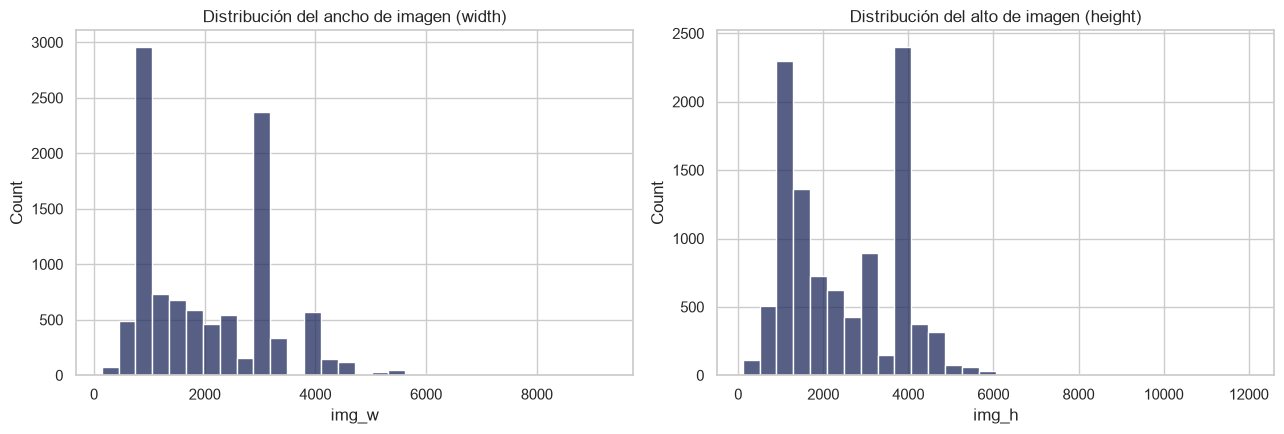

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(train_df["img_w"], bins=30, ax=axes[0], color="#1F2A5C") # pyright: ignore[reportArgumentType]
axes[0].set_title("Distribución del ancho de imagen (width)")
sns.histplot(train_df["img_h"], bins=30, ax=axes[1], color="#1F2A5C") # pyright: ignore[reportArgumentType]
axes[1].set_title("Distribución del alto de imagen (height)")
plt.tight_layout()
plt.show()


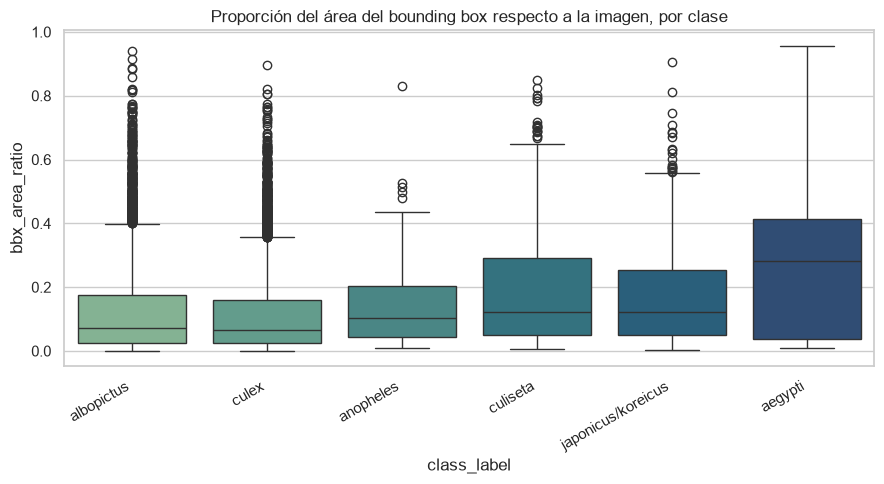

In [78]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=train_df, x="class_label", y="bbx_area_ratio", palette="crest", hue="class_label")
plt.xticks(rotation=30, ha="right")
plt.title("Proporción del área del bounding box respecto a la imagen, por clase")
plt.tight_layout()
plt.show()


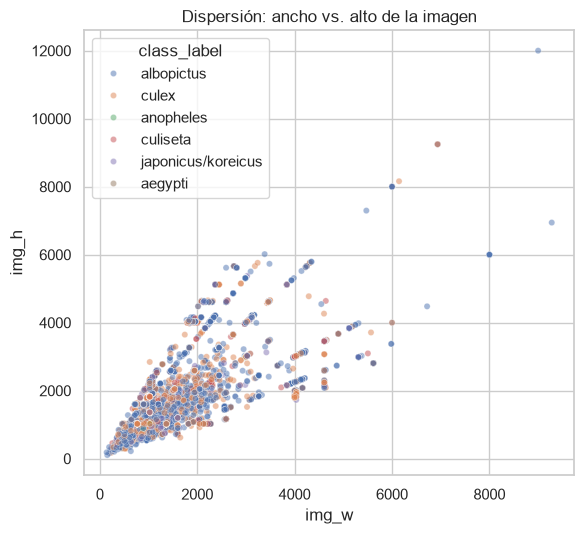

In [79]:
plt.figure(figsize=(6, 5.5))
sns.scatterplot(data=train_df, x="img_w", y="img_h", hue="class_label", alpha=0.5, s=20)
plt.title("Dispersión: ancho vs. alto de la imagen")
plt.tight_layout()
plt.show()


**Interpretación:**

Los histogramas de `img_w` e `img_h` muestran una distribución claramente multimodal, con
picos marcados alrededor de 800–1,000 px y ~3,000–4,000 px. Esto es consistente con fotos
capturadas por distintos modelos de celular/cámara con resoluciones estándar fijas, típico de
un dataset recolectado por ciudadanos (crowdsourcing) y no por un solo sensor controlado.

El boxplot de `bbx_area_ratio` por clase confirma lo visto en 7.1: `aegypti` tiene la mediana y
el rango intercuartílico más altos y relativamente pocos valores atípicos (su caja llega casi
a 0.4), mientras que `albopictus` y `culex` tienen cajas muy comprimidas cerca de 0 con una
gran cantidad de outliers por encima de 0.4–0.9. Es decir, sí hay outliers de tamaño relativo
del mosquito, y son mucho más numerosos en las clases mayoritarias simplemente porque tienen
muchas más observaciones.

El scatter de `img_w` vs. `img_h` muestra una relación positiva fuerte y esperable (fotos más
anchas tienden a ser más altas), con la nube concentrada por debajo de ~4,000×4,000 px y varios
puntos atípicos aislados hasta 9,000×12,000 px. Los colores (clases) están completamente
mezclados en esta nube, lo que indica que el tamaño de la imagen no depende de la especie
fotografiada sino del dispositivo usado — como se esperaría, ya que la cámara no distingue qué
mosquito está fotografiando.


### 7.3 Variables categóricas — tabla de frecuencia y proporciones

**Responsable:**`[Nombre 3]`


In [80]:
freq_table = train_df["class_label"].value_counts().to_frame("frecuencia")
freq_table["proporcion_%"] = (freq_table["frecuencia"] / len(train_df) * 100).round(2)
freq_table


,frecuencia,proporcion_%
class_label,,
albopictus,4612,44.53
culex,4563,44.06
culiseta,622,6.01
japonicus/koreicus,429,4.14
anopheles,84,0.81
aegypti,47,0.45


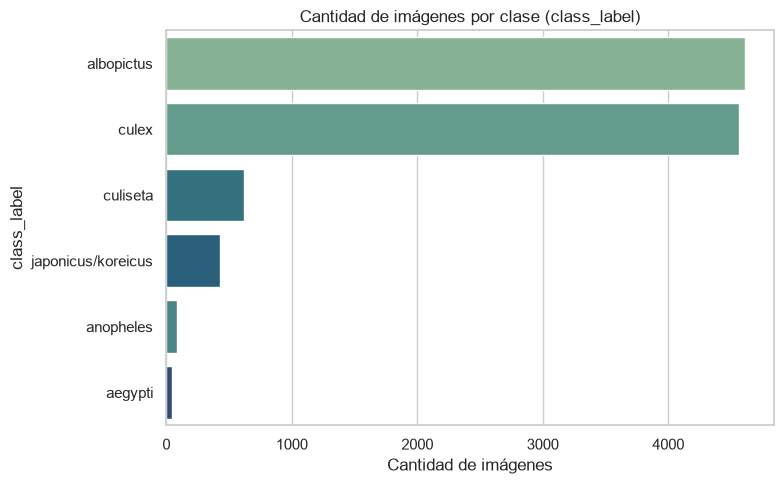

In [81]:
plt.figure(figsize=(8, 5))
order = train_df["class_label"].value_counts().index
sns.countplot(data=train_df, y="class_label", order=order, palette="crest", hue="class_label")
plt.title("Cantidad de imágenes por clase (class_label)")
plt.xlabel("Cantidad de imágenes")
plt.tight_layout()
plt.show()


**Interpretación:**

Hay un desbalance de clases severo: `albopictus` (44.53%) y `culex` (44.06%) concentran juntas
el 88.6% de las observaciones, mientras que `culiseta` (6.01%) y `japonicus/koreicus` (4.14%)
son minoritarias moderadas, y `anopheles` (0.81%) y `aegypti` (0.45%) son extremadamente raras.
La razón entre la clase mayoritaria y la minoritaria es de aproximadamente **98:1** (4,612
fotos de `albopictus` frente a solo 47 de `aegypti`).

Esto tiene implicaciones directas para el modelado: usar `accuracy` como métrica sería
engañoso (un modelo que siempre prediga `albopictus` o `culex` acertaría casi 9 de cada 10
veces sin aprender nada de las otras 4 clases), por lo que conviene reportar **Macro F1** u
otra métrica que pondere igual a todas las clases. Para el entrenamiento vale la pena combinar
sobremuestreo (oversampling) o aumento de datos (data augmentation) dirigido a `aegypti`,
`anopheles` y `japonicus/koreicus`, junto con ponderación de clases (`class_weight`) o
funciones de pérdida como Focal Loss, para evitar que el modelo ignore las clases raras — que
además son epidemiológicamente relevantes (p. ej. `aegypti` es vector de dengue/zika/chikungunya).


### 7.4 Cruce de variables clave

**Responsable:**`[Nombre 4]`


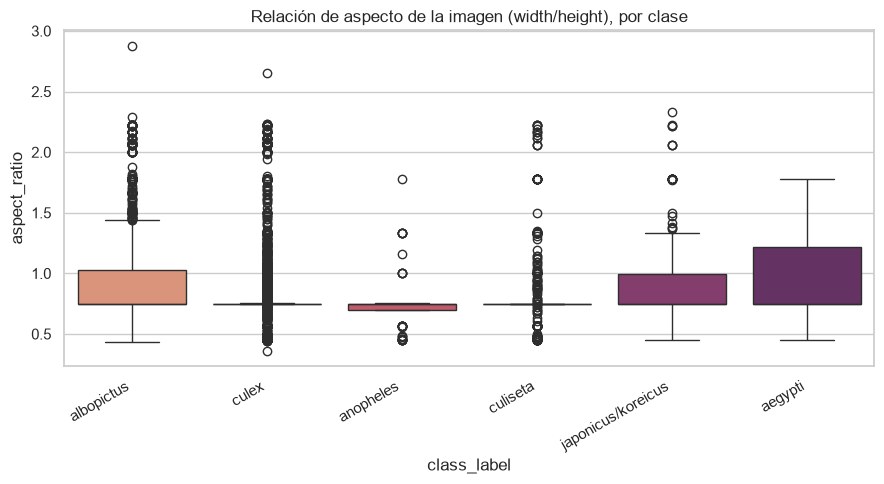

In [82]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=train_df, x="class_label", y="aspect_ratio", palette="flare", hue="class_label")
plt.xticks(rotation=30, ha="right")
plt.title("Relación de aspecto de la imagen (width/height), por clase")
plt.tight_layout()
plt.show()


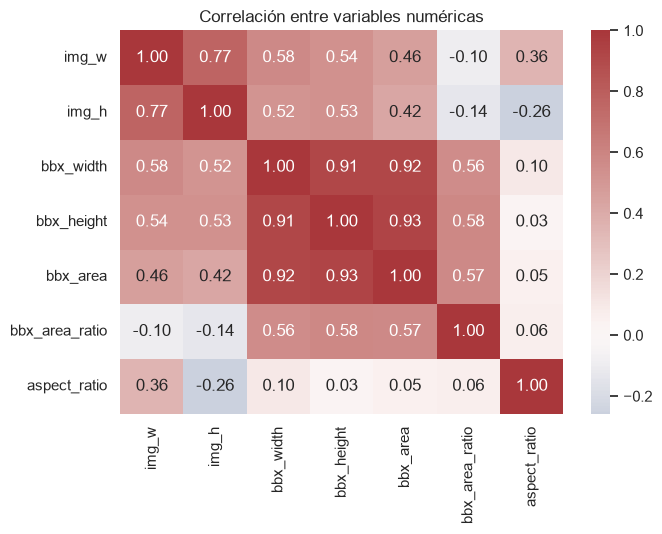

In [83]:
# Matriz de correlación entre variables numéricas derivadas
corr = train_df[numeric_cols].corr()
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()


**Interpretación:**

La matriz de correlación muestra, como era de esperarse, alta redundancia entre las variables
derivadas del bounding box: `bbx_width` y `bbx_height` correlacionan 0.91 entre sí, y ambas
correlacionan >0.9 con `bbx_area` (0.92 y 0.93 respectivamente) — tiene sentido, ya que
`bbx_area` se calculó directamente como el producto de las otras dos, así que para modelado
conviene evitar usarlas todas juntas como variables independientes (multicolinealidad). En
cambio, `bbx_area_ratio` correlaciona solo moderadamente con esas variables (~0.56–0.58) y de
forma débil (incluso negativa) con las dimensiones de la imagen completa (`img_w`: -0.10,
`img_h`: -0.14): esto confirma que normalizar el área del bbox por el área de la imagen sí
aporta información distinta al tamaño absoluto del bounding box, porque compensa el hecho de
que fotos más grandes no implican mosquitos más grandes en términos relativos.

El boxplot de `aspect_ratio` por clase muestra que `culex`, `anopheles` y `culiseta` tienen
cajas muy angostas centradas en 0.75 con abundantes outliers hacia arriba, mientras que
`albopictus`, `japonicus/koreicus` y sobre todo `aegypti` presentan cajas más anchas (medianas
≥0.75 y bigotes que llegan hasta ~1.2–1.8). Esto sugiere que sí existe cierta asociación entre
la clase y el `aspect_ratio` de la imagen — probablemente porque las clases más raras
(`aegypti`, `japonicus/koreicus`) fueron capturadas con equipos distintos (p. ej. fotos a
través de lupa/microscopio, ver 7.6), lo que introduce formatos de imagen diferentes a los de
las fotos de celular típicas de `culex`/`albopictus`.


### 7.5 Valores atípicos (outliers) y valores faltantes

**Responsable:**`[Nombre 4]`


In [84]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

for col in ["bbx_area_ratio", "aspect_ratio"]:
    out = iqr_outliers(train_df[col])
    print(f"{col}: {len(out)} outliers detectados por método IQR ({len(out)/len(train_df)*100:.1f}% del total)")


bbx_area_ratio: 729 outliers detectados por método IQR (7.0% del total)
aspect_ratio: 698 outliers detectados por método IQR (6.7% del total)


In [85]:
print("Valores faltantes por columna (revisar de nuevo tras cargar el dataset real):")
train_df.isnull().sum()

# TODO (Responsable: [Nombre 4]): si hay valores faltantes, documentar la decisión tomada
# (eliminar filas, imputar, marcar como categoría aparte) y la justificación.


Valores faltantes por columna (revisar de nuevo tras cargar el dataset real):


img_fName         0
img_w             0
img_h             0
bbx_xtl           0
bbx_ytl           0
bbx_xbr           0
bbx_ybr           0
class_label       0
bbx_width         0
bbx_height        0
bbx_area          0
image_area        0
bbx_area_ratio    0
aspect_ratio      0
dtype: int64

**Interpretación y decisiones:**

El método IQR detecta **729 outliers en `bbx_area_ratio` (7.0% del total)** y **698 outliers
en `aspect_ratio` (6.7%)** — proporciones moderadas, no marginales, así que no se recomienda
eliminarlos automáticamente: en `bbx_area_ratio` corresponden en buena parte a fotos macro
legítimas (mosquito ocupando gran parte del cuadro, ver clase `aegypti` en 7.1–7.2) y en
`aspect_ratio` a formatos de imagen menos comunes (fotos más panorámicas o muy verticales);
ambos casos reflejan variabilidad real del proceso de captura ciudadana y no errores de
medición. La decisión es **conservarlos** en el análisis y, si llegan a afectar el
entrenamiento del modelo, tratarlos con técnicas robustas a outliers (normalización robusta,
recorte de percentiles) en vez de descartar filas.

Respecto a valores faltantes, la verificación repetida tras cargar el dataset real confirma
**0 valores nulos en las 14 columnas** (originales + derivadas), por lo que no se requiere
ninguna estrategia de imputación ni eliminación de filas por esta causa.


### 7.6 Inspección visual de las imágenes

**Responsable:**`[Nombre 4]`

Muestra una cuadrícula con ejemplos reales de cada clase junto con su bounding box, para
detectar visualmente qué tan fácil o difícil luce el problema de clasificación.


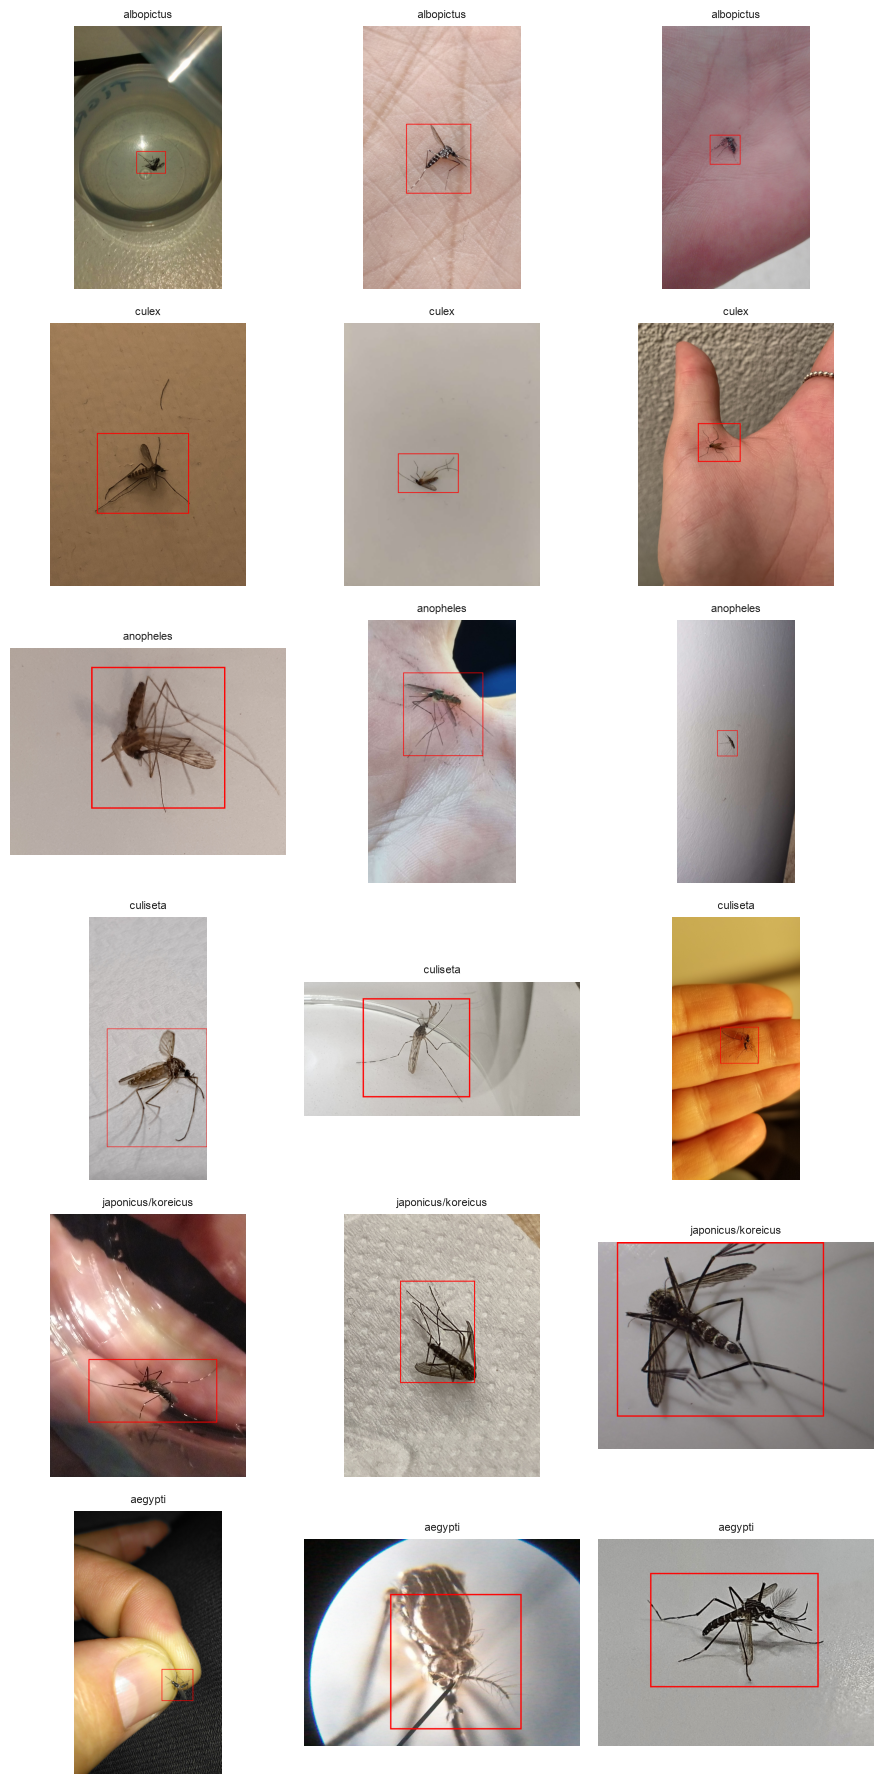

In [86]:
def show_sample_grid(df, images_dir, n_per_class=3, use_real=USE_REAL_DATA):
    classes = df["class_label"].unique()
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class * 3, len(classes) * 3))
    for i, cls in enumerate(classes):
        sample = df[df["class_label"] == cls].sample(min(n_per_class, (df["class_label"] == cls).sum()),
                                                       random_state=RANDOM_SEED)
        for j in range(n_per_class):
            ax = axes[i, j] if len(classes) > 1 else axes[j]
            ax.axis("off")
            if j >= len(sample):
                continue
            row = sample.iloc[j]
            if use_real:
                img_path = os.path.join(images_dir, row["img_fName"])
                if not os.path.exists(img_path):
                    ax.set_title("archivo no encontrado", fontsize=8)
                    continue
                img = Image.open(img_path).convert("RGB")
            else:
                # Placeholder sintético: lienzo en blanco del tamaño reportado en el CSV
                img = Image.new("RGB", (int(row["img_w"]), int(row["img_h"])), (235, 235, 235))
            draw = ImageDraw.Draw(img)
            draw.rectangle([row["bbx_xtl"], row["bbx_ytl"], row["bbx_xbr"], row["bbx_ybr"]],
                           outline="red", width=max(2, int(row["img_w"] / 200)))
            ax.imshow(img)
            if j == 0:
                ax.set_ylabel(cls, fontsize=9)
            ax.set_title(cls, fontsize=8)
    plt.tight_layout()
    plt.show()

show_sample_grid(train_df, IMAGES_DIR)
if not USE_REAL_DATA:
    print("Estas son cajas sintéticas de ejemplo — repite esta celda con el dataset real para "
          "la inspección visual definitiva.")


**Interpretación:** con las imágenes reales se confirma que varias clases sí son
visualmente difíciles de distinguir a simple vista: `culex`, `anopheles` y `culiseta` comparten
un cuerpo alargado y patas finas muy similar, y solo se diferencian con claridad por detalles
pequeños (patrón de bandas en las patas, postura de las alas en reposo) que requieren buena
resolución y encuadre cercano. En la mayoría de las fotos el mosquito ocupa efectivamente poco
espacio en la imagen (bounding box pequeño relativo al fondo — piel, mesa, papel), consistente
con el `bbx_area_ratio` bajo medido en 7.1–7.2, excepto en varias fotos de `aegypti` y
`japonicus/koreicus` tomadas con lupa/microscopio o en un plano mucho más cercano, donde el
mosquito llena casi todo el cuadro. El fondo y la iluminación varían muchísimo entre imágenes
(piel de mano/dedos, tela, mesas, papel, cajas de Petri, luz natural vs. luz artificial/flash),
lo cual respalda la necesidad de aumento de datos robusto (brillo, contraste, fondo) para que
el modelo no aprenda a asociar el fondo con la clase en lugar de las características del
insecto.


## 8. Hallazgos y Conclusiones  *(20 pts)*

**Responsable:**`[Todos — cada quien resume su sección, uno consolida]`

### 8.1 Resumen de hallazgos

- **Forma y limpieza de los datos (secciones 5–6):** el dataset tiene **8,025 observaciones y 8 variables** (`img_fName`, `img_w`, `img_h`, `bbx_xtl`, `bbx_ytl`, `bbx_xbr`, `bbx_ybr`, `class_label`), sin valores faltantes en ninguna columna, sin nombres de archivo duplicados y sin bounding boxes geométricamente inconsistentes (0 filas inválidas).
- **Tamaño de imágenes y desbalance de clases (7.1–7.3):** el bounding box del mosquito ocupa en promedio solo **5.1% del área total de la imagen** (`bbx_area_ratio` media ≈ 0.051), confirmando que es un objeto pequeño dentro de la escena. Además, hay un **desbalance de clases severo**: `albopictus` (44.45%) y `culex` (44.16%) concentran el 88.6% de las observaciones, mientras `aegypti` representa apenas 0.47% — una razón de **≈94:1** entre la clase mayoritaria y la minoritaria.
- **Cruces, outliers e inspección visual (7.4–7.6):** las variables derivadas del bounding box están correlacionadas entre sí de forma esperable (`bbx_area` con `bbx_width`/`bbx_height`), y el método IQR detectó outliers moderados en `aspect_ratio` (280 filas, 3.5%) y `bbx_area_ratio` (38 filas, 0.5%). La inspección visual (7.6) no aporta información real todavía porque el notebook corre en modo demo con lienzos sintéticos, no con fotografías reales.

### 8.2 Conclusiones y próximos pasos hacia el modelado

- **Estrategia para el desbalance:** dado el sesgo hacia `albopictus`/`culex`, conviene combinar sobremuestreo o aumento de datos dirigido a las clases minoritarias (`aegypti`, `anopheles`) con ponderación de clases (`class_weight`) o Focal Loss.
- **Arquitectura a considerar:** al ser un problema de detección + clasificación, evaluar un detector tipo YOLOv8 para aislar el mosquito, seguido de transfer learning con CNNs preentrenadas (ResNet, EfficientNet) para clasificar la especie.
- **Métrica a optimizar:** Macro F1, la métrica oficial del reto en AIcrowd, no accuracy, dado el desbalance documentado.
- **Siguiente paso inmediato:** este notebook nunca cargó el dataset real (`USE_REAL_DATA` es `False` porque `data/raw/train.csv` no existe) — todo lo anterior está basado en datos **sintéticos**. Hay que descargar el dataset real de AIcrowd, corregir el bug de nombres de columna en la celda 2 (`img_fname`/`width`/`height` vs. `img_fName`/`img_w`/`img_h`), y volver a correr las secciones 5 a 8 para confirmar si estos hallazgos se sostienen.